In [1]:
import numpy as np
import pandas as pd

In [23]:
order = pd.read_csv("/content/cleaned_orders.csv")
cust = pd.read_csv("/content/Customer_cleaned_data.csv")
prod = pd.read_csv("/content/cleaned_Products.csv")
location = pd.read_csv("/content/cleaned_geolocation.csv")
items = pd.read_csv("/content/cleaned_items.csv")
payment = pd.read_csv("/content/cleaned_payment.csv")
review = pd.read_csv("/content/cleaned_review.csv")
seller = pd.read_csv("/content/olist_sellers_dataset.csv")

In [85]:
df_list = [order, cust, prod, location, items, payment, review, seller]


for df_obj in df_list:
  df_obj.info()
  print('\n\n\n')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-n

Order

In [5]:
order.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,2017-10-02 11:07:00,2017-10-04 19:55:00,2017-10-10 21:25:00,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,2018-07-26 03:24:00,2018-07-26 14:31:00,2018-08-07 15:27:00,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,2018-08-08 08:55:00,2018-08-08 13:50:00,2018-08-17 18:06:00,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:00,2017-11-18 19:45:00,2017-11-22 13:39:00,2017-12-02 00:28:00,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:00,2018-02-13 22:20:00,2018-02-14 19:46:00,2018-02-16 18:17:00,2018-02-26


In [11]:
order.shape

(99441, 8)

In [6]:
order.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

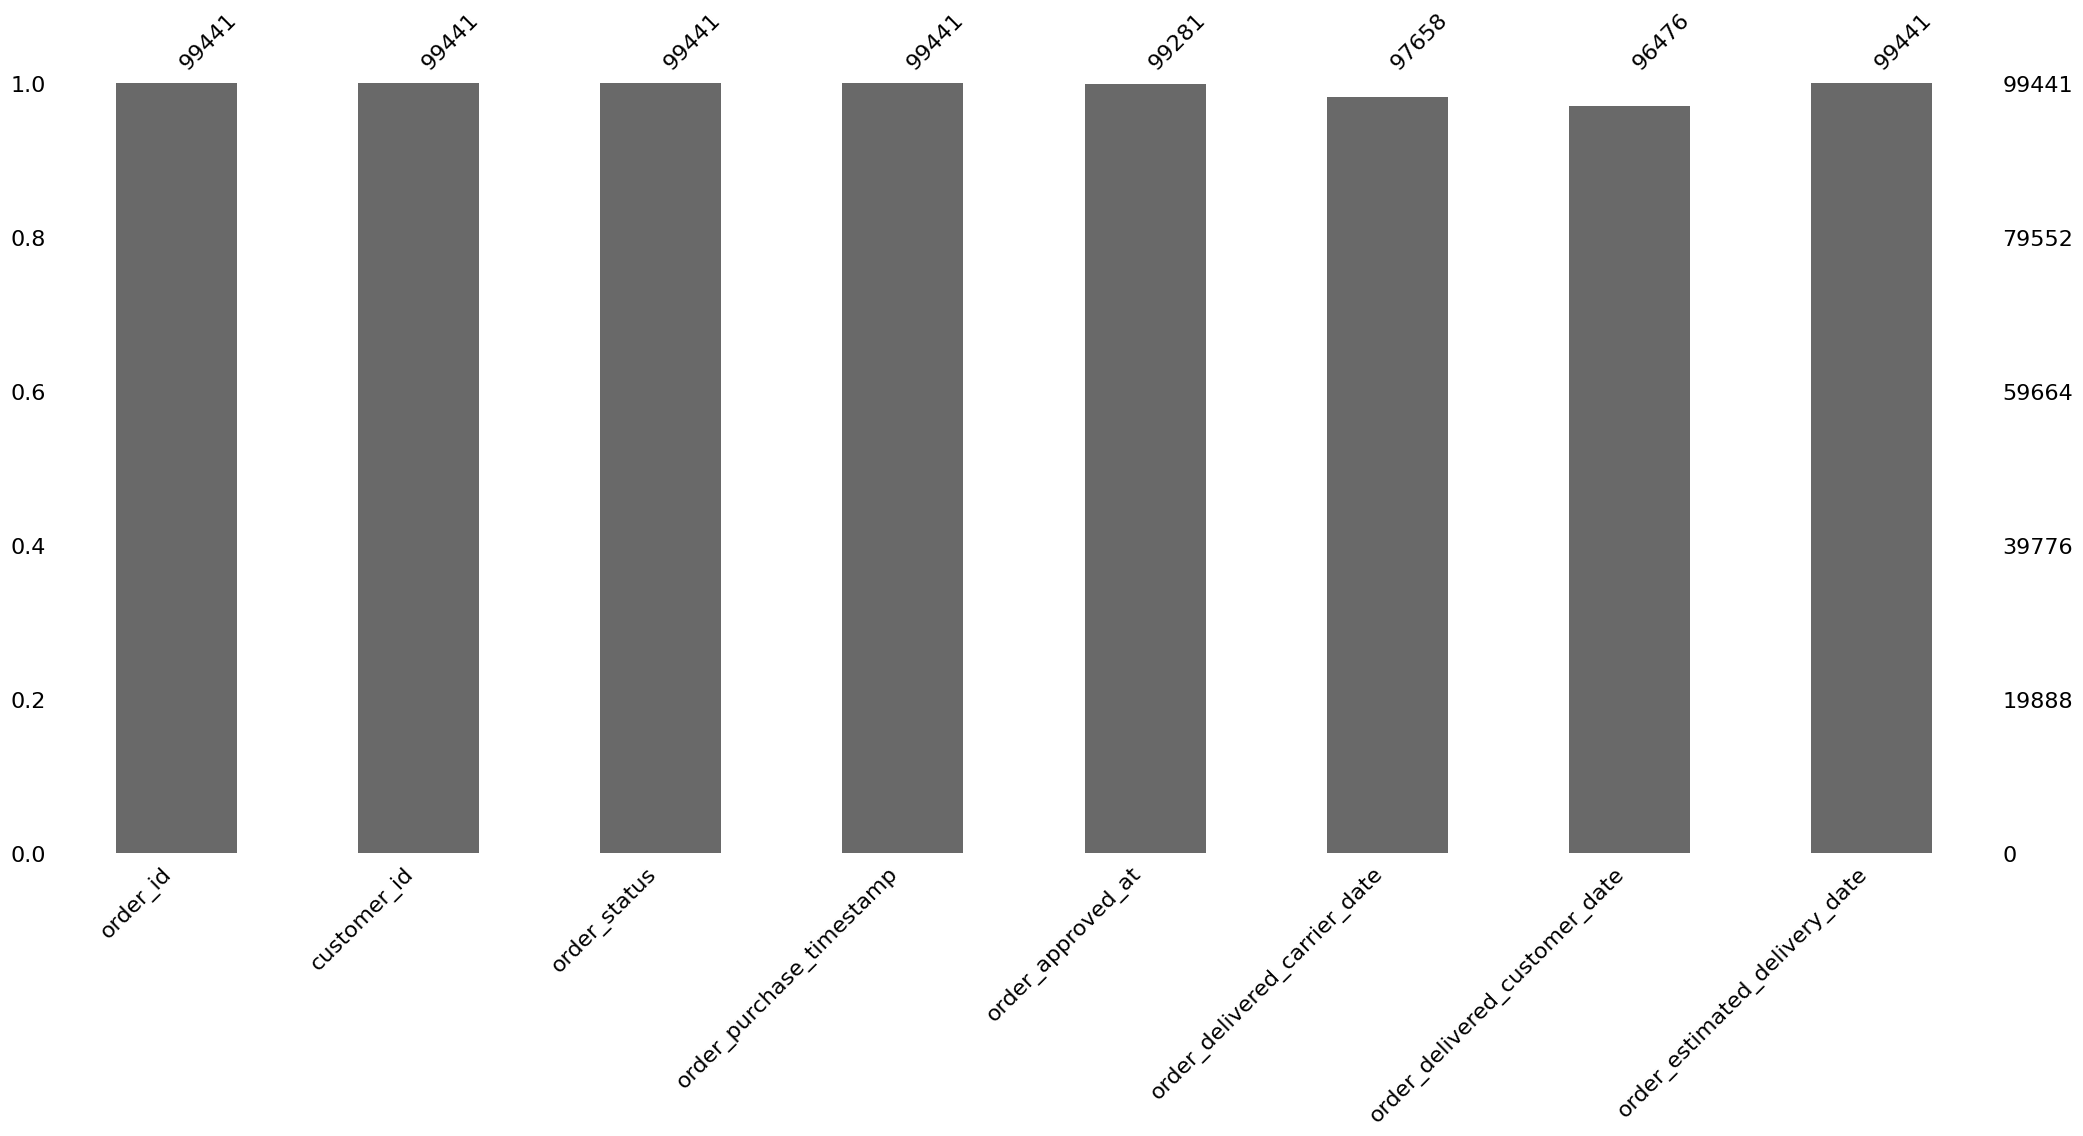

In [9]:
import missingno as msno
import matplotlib.pyplot as plt

msno.bar(order)

plt.show()

In [17]:
order.duplicated().sum()

np.int64(0)

In [19]:
order.apply(lambda col: col.duplicated().sum())

,0
order_id,0
customer_id,0
order_status,99433
order_purchase_timestamp,10652
order_approved_at,48978
order_delivered_carrier_date,37896
order_delivered_customer_date,23791
order_estimated_delivery_date,98982


seller

In [24]:
seller.shape

(3095, 4)

In [25]:
seller.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


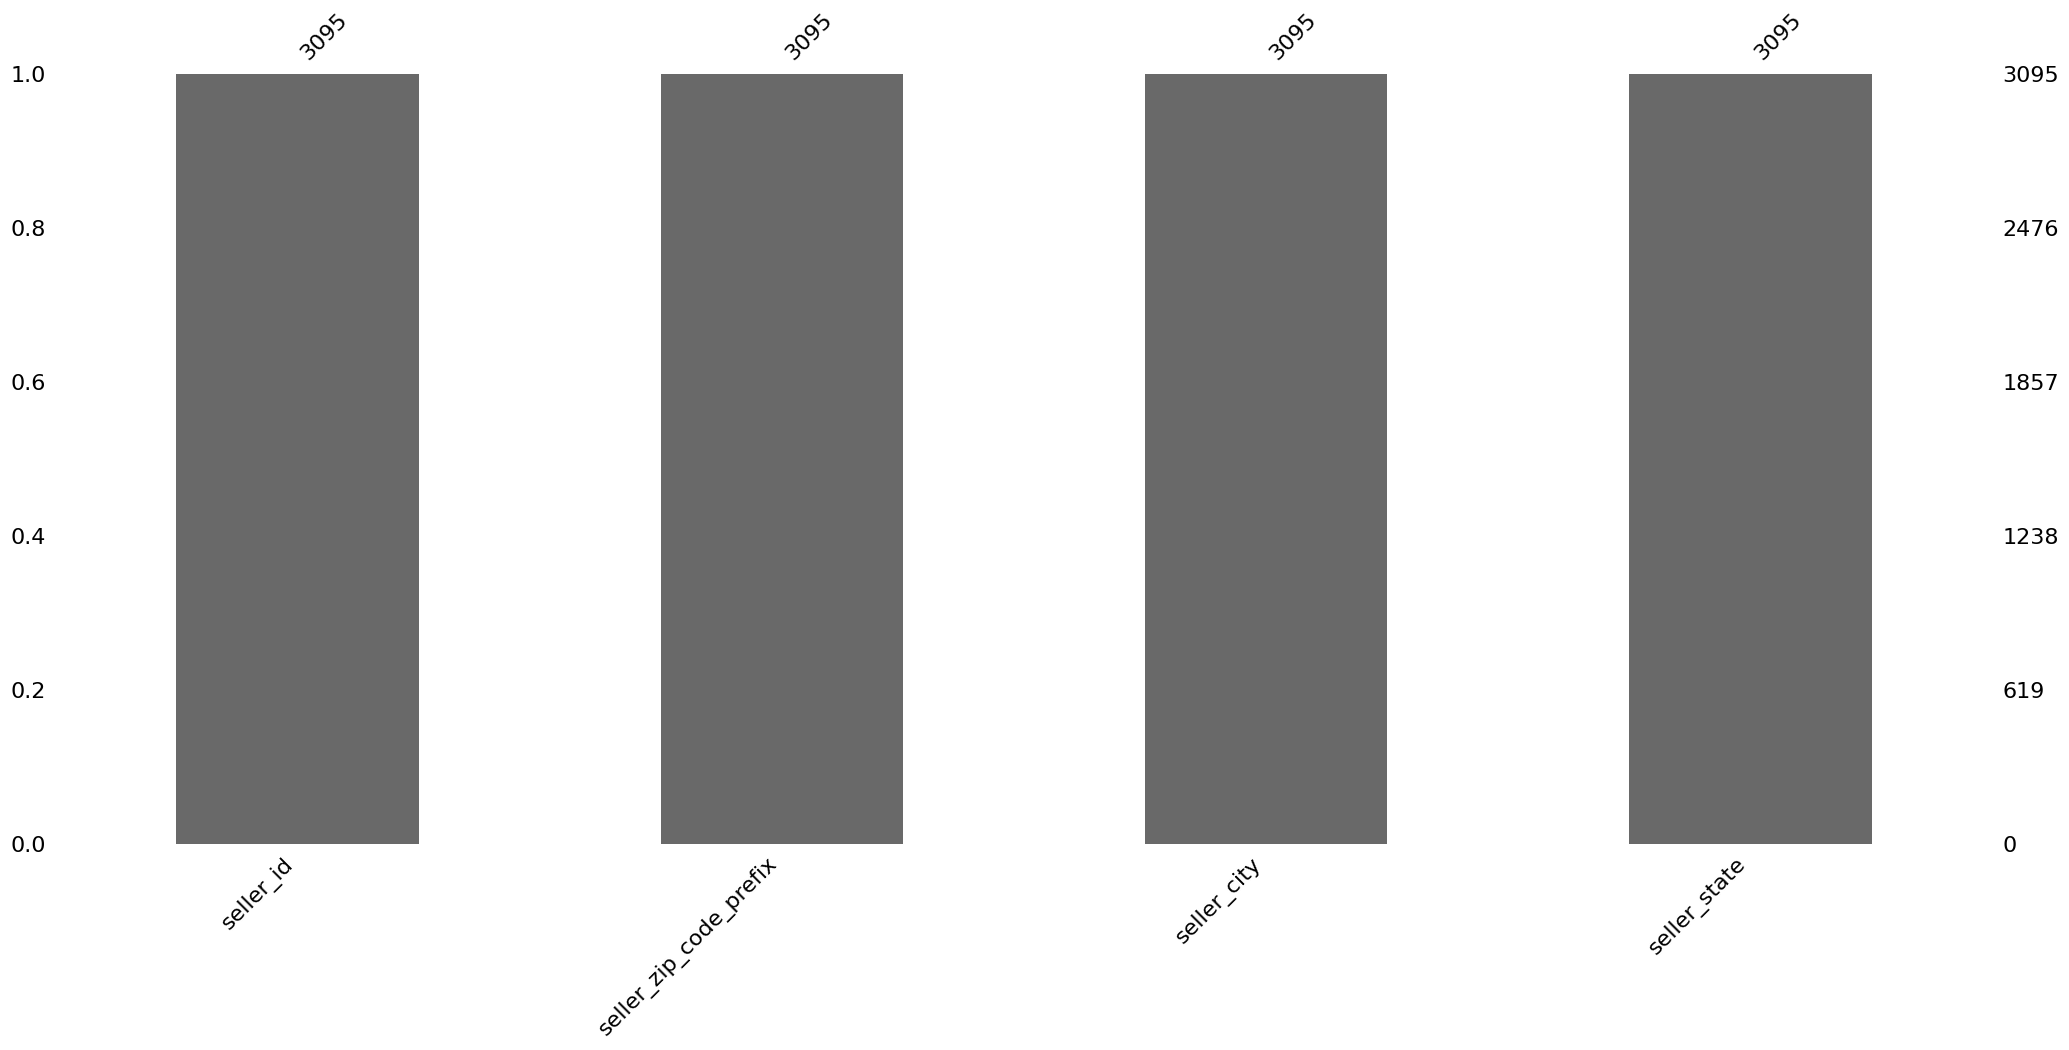

In [26]:
msno.bar(seller)

plt.show()

In [29]:
seller.duplicated().sum()

np.int64(0)

In [28]:
seller.apply(lambda col: col.duplicated().sum())

,0
seller_id,0
seller_zip_code_prefix,849
seller_city,2484
seller_state,3072


In [35]:
print(seller['seller_city'].value_counts().to_string())

seller_city
sao paulo                                   694
curitiba                                    127
rio de janeiro                               96
belo horizonte                               68
ribeirao preto                               52
guarulhos                                    50
ibitinga                                     49
santo andre                                  45
campinas                                     41
maringa                                      40
sao jose do rio preto                        33
sorocaba                                     32
sao bernardo do campo                        32
osasco                                       32
porto alegre                                 28
brasilia                                     28
londrina                                     26
goiania                                      23
joinville                                    22
blumenau                                     21
franca                      

In [86]:
city_corrections = {
    'sao pauo': 'sao paulo',
    'sao paluo': 'sao paulo',
    'sao paulop': 'sao paulo',
    'sao  paulo': 'sao paulo',
    'sao paulo - sp': 'sao paulo',
    'sao paulo sp': 'sao paulo',
    'sao paulo / sao paulo': 'sao paulo',
    'são paulo': 'sao paulo',

    'ribeirao pretp': 'ribeirao preto',
    'robeirao preto': 'ribeirao preto',
    'riberao preto': 'ribeirao preto',

    'mogi das cruses': 'mogi das cruzes',
    'floranopolis': 'florianopolis',
    'cascavael': 'cascavel',
    'sando andre': 'santo andre',
    'garulhos': 'guarulhos',
    'belo horizont': 'belo horizonte',

    'sao bernardo do capo': 'sao bernardo do campo',
    'sao jose dos pinhas': 'sao jose dos pinhais',
    'balenario camboriu': 'balneario camboriu',

    'sao jose do rio pret': 'sao jose do rio preto',
    'scao jose do rio pardo': 'sao jose do rio pardo',

    'tabao da serra': 'taboao da serra',
    'paincandu': 'paicandu',
    'juzeiro do norte': 'juazeiro do norte',
    'ferraz de  vasconcelos': 'ferraz de vasconcelos'
}


In [88]:
seller['seller_city']=seller['seller_city'].replace(city_corrections)

In [89]:

city_corrections.update({
    'mogi das cruzes / sp': 'mogi das cruzes',
    'sbc/sp': 'sao bernardo do campo',
    'sbc': 'sao bernardo do campo',
    'pinhais/pr': 'pinhais',
    'maua/sao paulo': 'maua',
    'santo andre/sao paulo': 'santo andre',
    'carapicuiba / sao paulo': 'carapicuiba',
    'ribeirao preto / sao paulo': 'ribeirao preto',
    'cariacica / es': 'cariacica',
    'pinhais/pr': 'pinhais',
    'auriflama/sp': 'auriflama',
    'lages - sc': 'lages',
    'brasilia df': 'brasilia',
    'novo hamburgo, rio grande do sul, brasil': 'novo hamburgo',
    'rio de janeiro, rio de janeiro, brasil': 'rio de janeiro',
    'rio de janeiro / rio de janeiro': 'rio de janeiro',
})

In [90]:
seller['seller_city']=seller['seller_city'].replace(city_corrections)

In [92]:
invalid = [
    '04482255',
    'vendas@creditparts.com.br'
]
seller.loc[seller['seller_city'].isin(invalid),'seller_city']=None

In [94]:
seller['seller_city'].nunique()

570

In [95]:
city_corrections = {
    'sp': 'sao paulo',
    'ao bernardo do campo': 'sao bernardo do campo',
    'sao  jose dos pinhais': 'sao jose dos pinhais',
    'sao sebastiao da grama/sp': 'sao sebastiao da grama',
    'jacarei / sao paulo': 'jacarei',
    'aguas claras df': 'aguas claras',
    'angra dos reis rj': 'angra dos reis',
    'andira-pr': 'andira',
    'barbacena/ minas gerais': 'barbacena',
    'rio de janeiro \rio de janeiro': 'rio de janeiro',
    's jose do rio preto': 'sao jose do rio preto',
    'paicandu': 'paicandu',
    'sp / sp': 'sao paulo',

    # Santa Barbara d'Oeste variations
    "santa barbara d'oeste": "santa barbara d'oeste",
    "santa barbara d´oeste": "santa barbara d'oeste",
    "santa barbara d oeste": "santa barbara d'oeste"
}

seller['seller_city'] = seller['seller_city'].replace(city_corrections)


In [96]:
seller['seller_city'].nunique()

560

In [100]:
city_mapping = {
    'rio de janeiro \\rio de janeiro': 'rio de janeiro',
    "sao miguel do oeste": "sao miguel d'oeste",
    'portoferreira': 'porto ferreira'
}

seller['seller_city'] = seller['seller_city'].replace(city_mapping)

In [102]:
seller['seller_city'].nunique()

557

In [101]:
print(seller['seller_city'].value_counts().index.tolist())

['sao paulo', 'curitiba', 'rio de janeiro', 'belo horizonte', 'ribeirao preto', 'guarulhos', 'ibitinga', 'santo andre', 'campinas', 'maringa', 'sao bernardo do campo', 'sao jose do rio preto', 'sorocaba', 'osasco', 'brasilia', 'porto alegre', 'londrina', 'goiania', 'joinville', 'blumenau', 'sao caetano do sul', 'franca', 'florianopolis', 'sao jose dos campos', 'caxias do sul', 'mogi das cruzes', 'limeira', 'santos', 'marilia', 'cascavel', 'jundiai', 'maua', 'bauru', 'barueri', 'sao carlos', 'sao jose dos pinhais', 'rio claro', 'uberlandia', 'presidente prudente', 'piracicaba', 'contagem', 'taboao da serra', 'atibaia', 'araraquara', 'carapicuiba', 'praia grande', 'birigui', 'brusque', 'juiz de fora', 'cotia', 'itajai', 'arapongas', 'catanduva', 'porto ferreira', 'americana', 'pinhais', 'itaquaquecetuba', 'salto', 'pedreira', 'diadema', 'santana de parnaiba', 'canoas', 'jaragua do sul', 'mogi guacu', 'palhoca', 'apucarana', 'jacarei', 'colombo', 'divinopolis', 'indaiatuba', 'niteroi', 't

In [98]:
seller[['seller_zip_code_prefix','seller_city']].drop_duplicates().shape[0]

2261

In [105]:
seller.to_csv('cleaned_sellers_new.csv',index=False)
from google.colab import files
files.download('cleaned_sellers.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

items

In [37]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [38]:
items.shape

(112650, 7)

<Axes: >

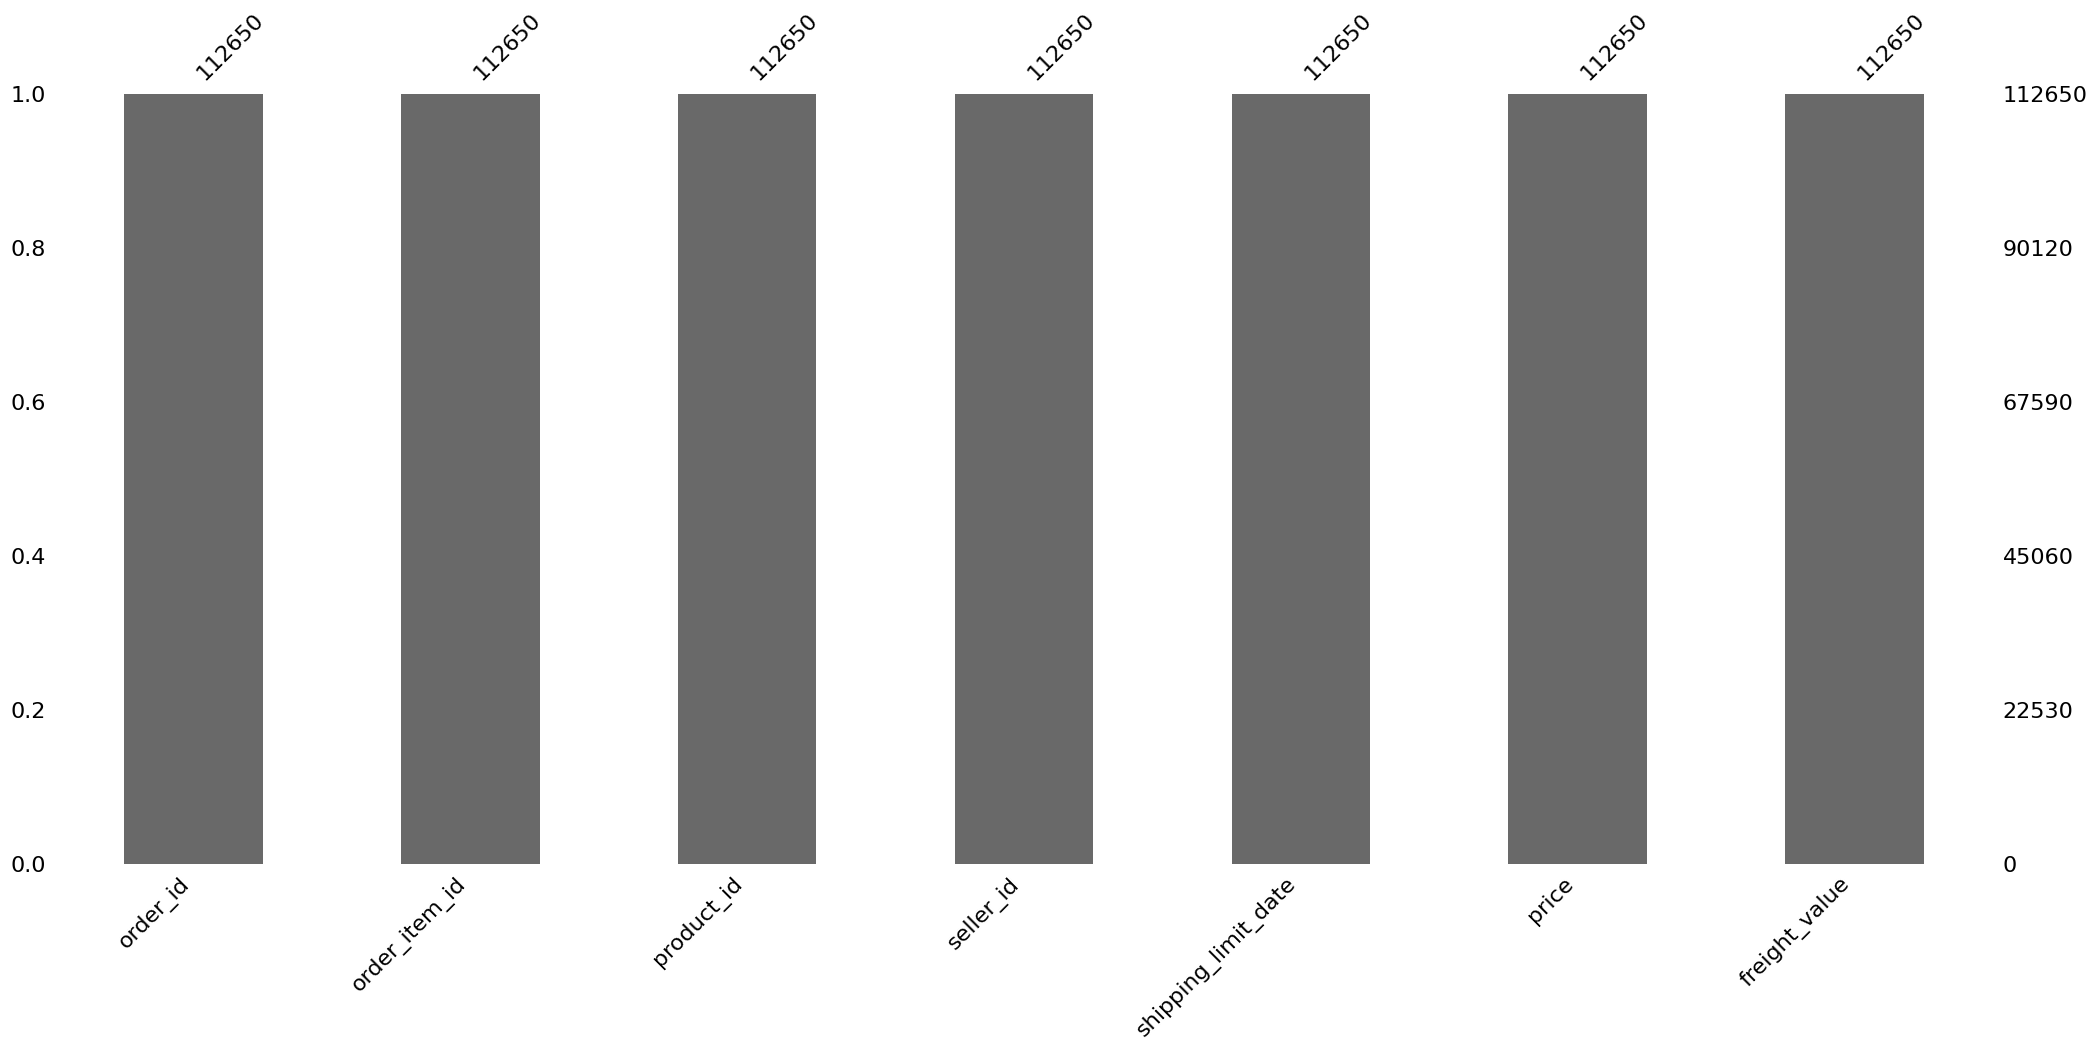

In [39]:
msno.bar(items)

In [40]:
items.duplicated().sum()

np.int64(0)

In [41]:
items.apply(lambda col: col.duplicated().sum())

,0
order_id,13984
order_item_id,112629
product_id,79699
seller_id,109555
shipping_limit_date,19332
price,106682
freight_value,105651


In [47]:
items[['order_id','seller_id','product_id','order_item_id']].duplicated().sum()

np.int64(0)

'order_id','seller_id','product_id','order_item_id' combination of these are going to become primary kry

customer

In [48]:
cust.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


<Axes: >

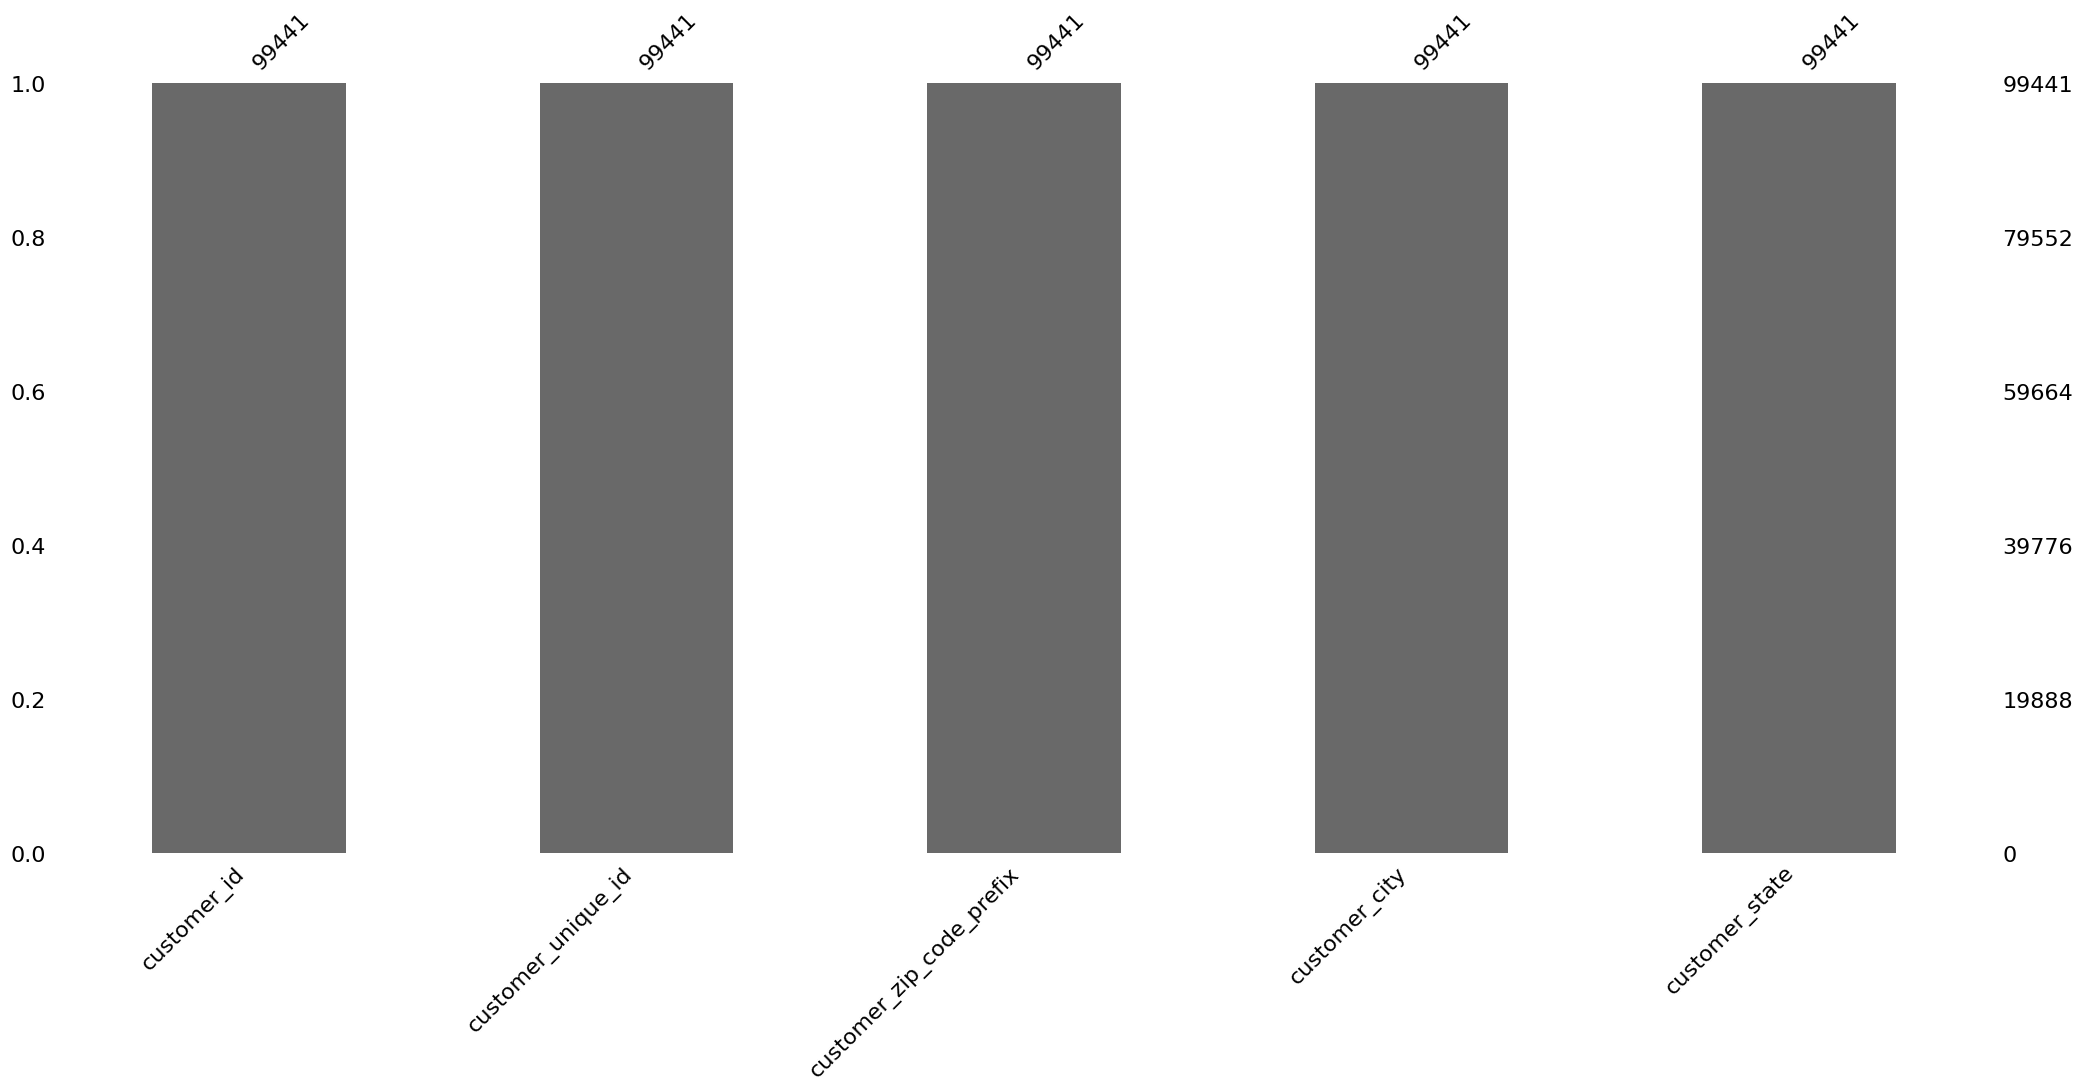

In [49]:
msno.bar(cust)

In [50]:
cust.apply(lambda col: col.duplicated().sum())

,0
customer_id,0
customer_unique_id,3345
customer_zip_code_prefix,84447
customer_city,95322
customer_state,99414


geolocation

In [51]:
location.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_state,geolocation_city
0,1037,-23.545621,-46.639292,SP,sao paulo
1,1046,-23.546081,-46.644820,SP,sao paulo
2,1046,-23.546129,-46.642951,SP,sao paulo
3,1041,-23.544392,-46.639499,SP,sao paulo
4,1035,-23.541578,-46.641607,SP,sao paulo


In [52]:
location.shape

(720404, 5)

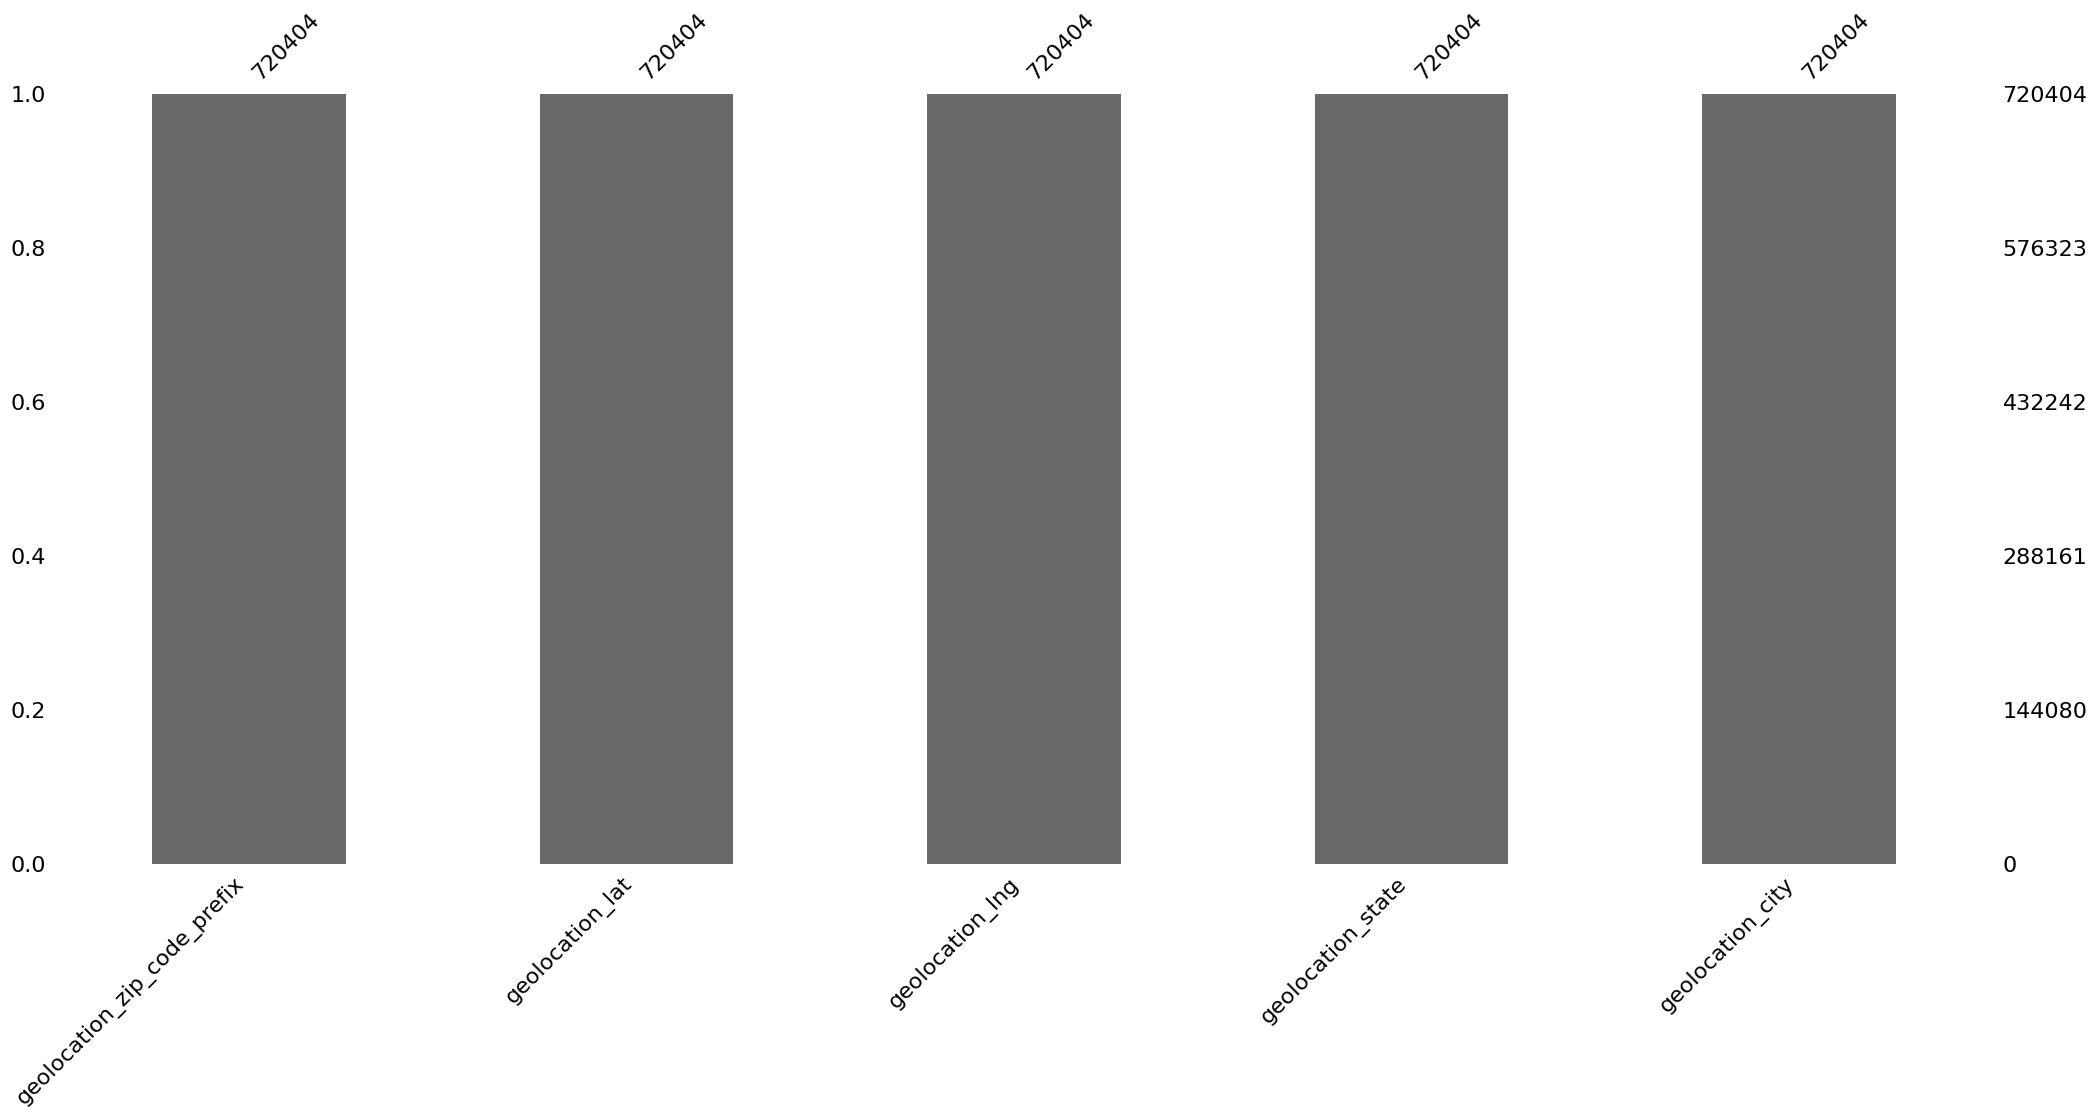

In [55]:
msno.bar(location)
plt.show()

In [56]:
location.apply(lambda col: col.duplicated().sum())

,0
geolocation_zip_code_prefix,701389
geolocation_lat,3055
geolocation_lng,2791
geolocation_state,720377
geolocation_city,714474


In [59]:
location.duplicated().sum()

np.int64(0)

payments

In [61]:
payment.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


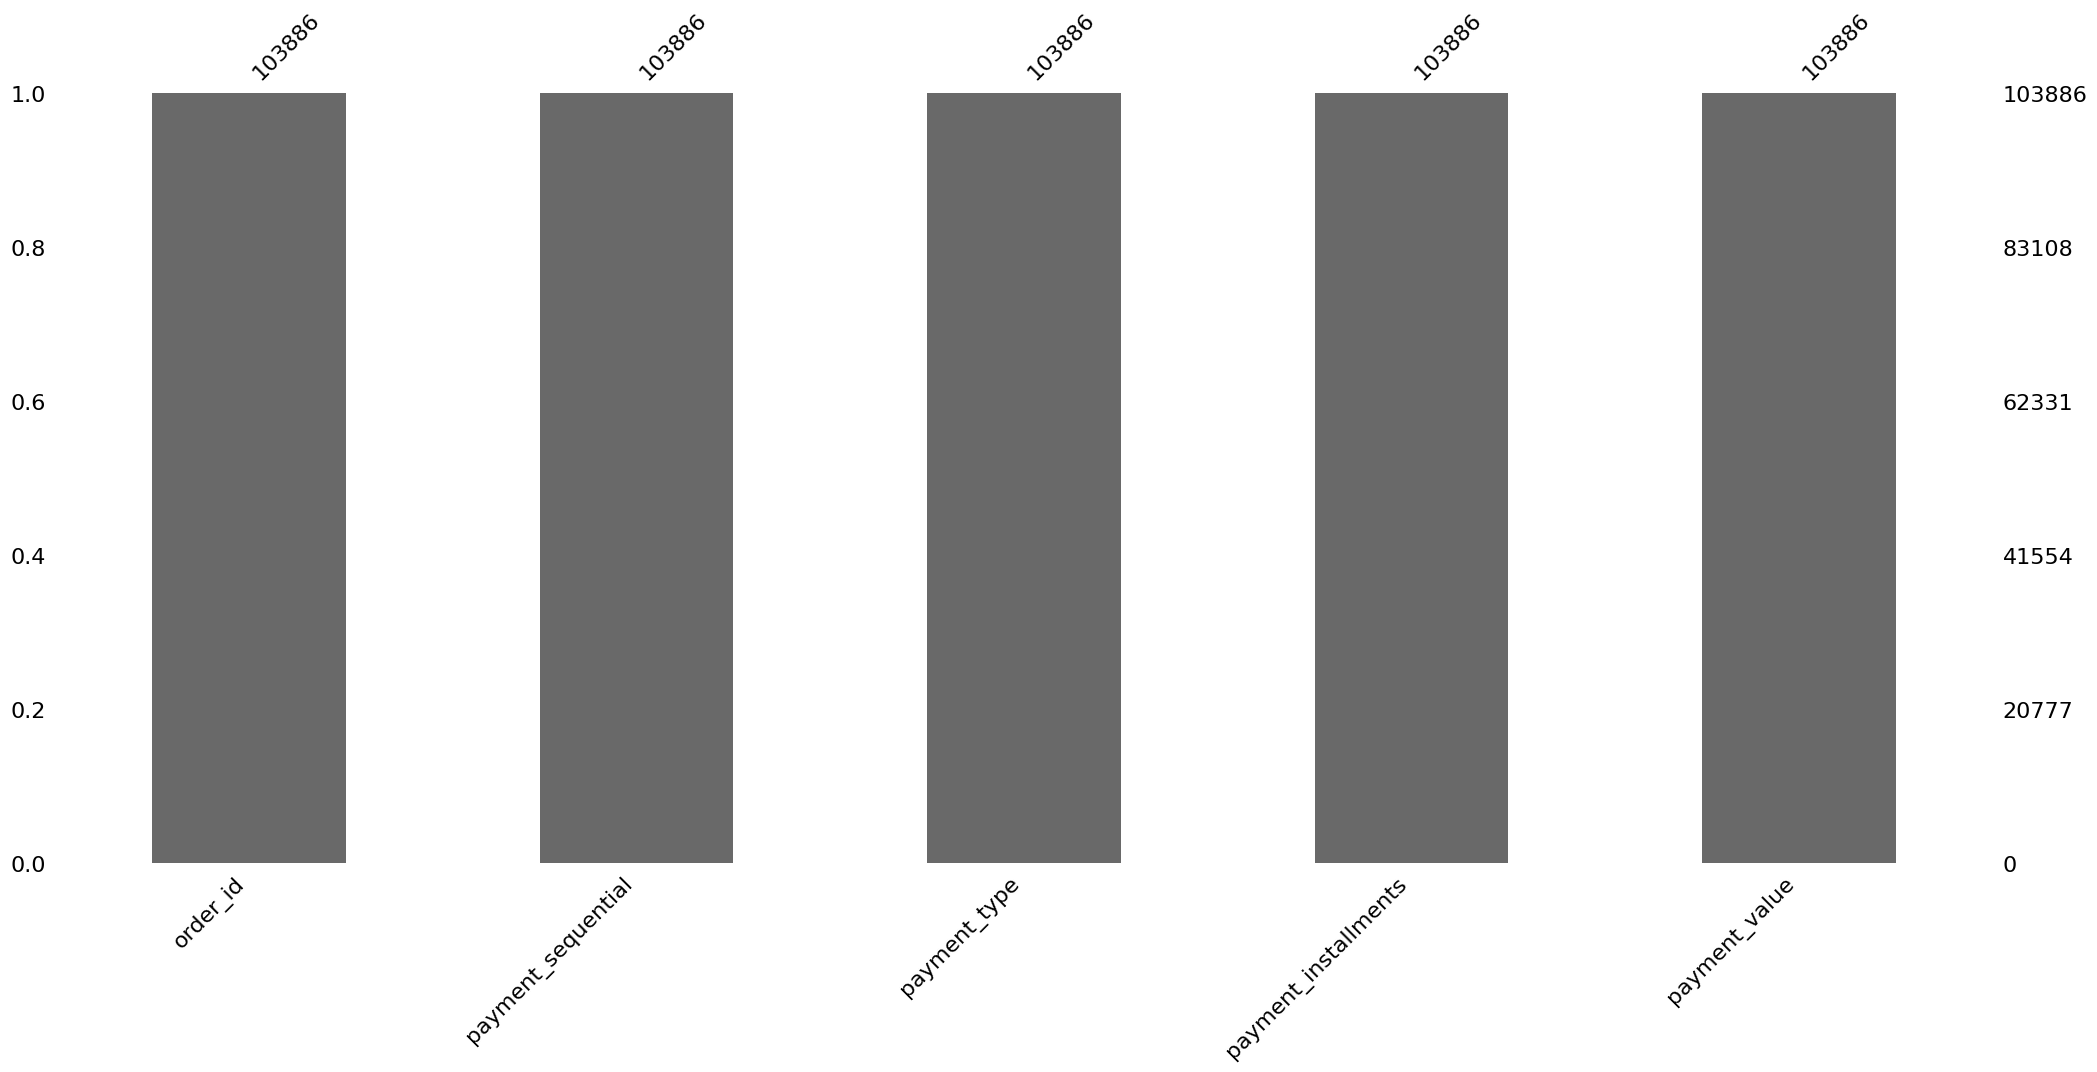

In [62]:
msno.bar(payment)
plt.show()

In [63]:
payment.duplicated().sum()

np.int64(0)

In [64]:
payment.apply(lambda col: col.duplicated().sum())

,0
order_id,4446
payment_sequential,103857
payment_type,103881
payment_installments,103862
payment_value,74809


review

In [65]:
review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


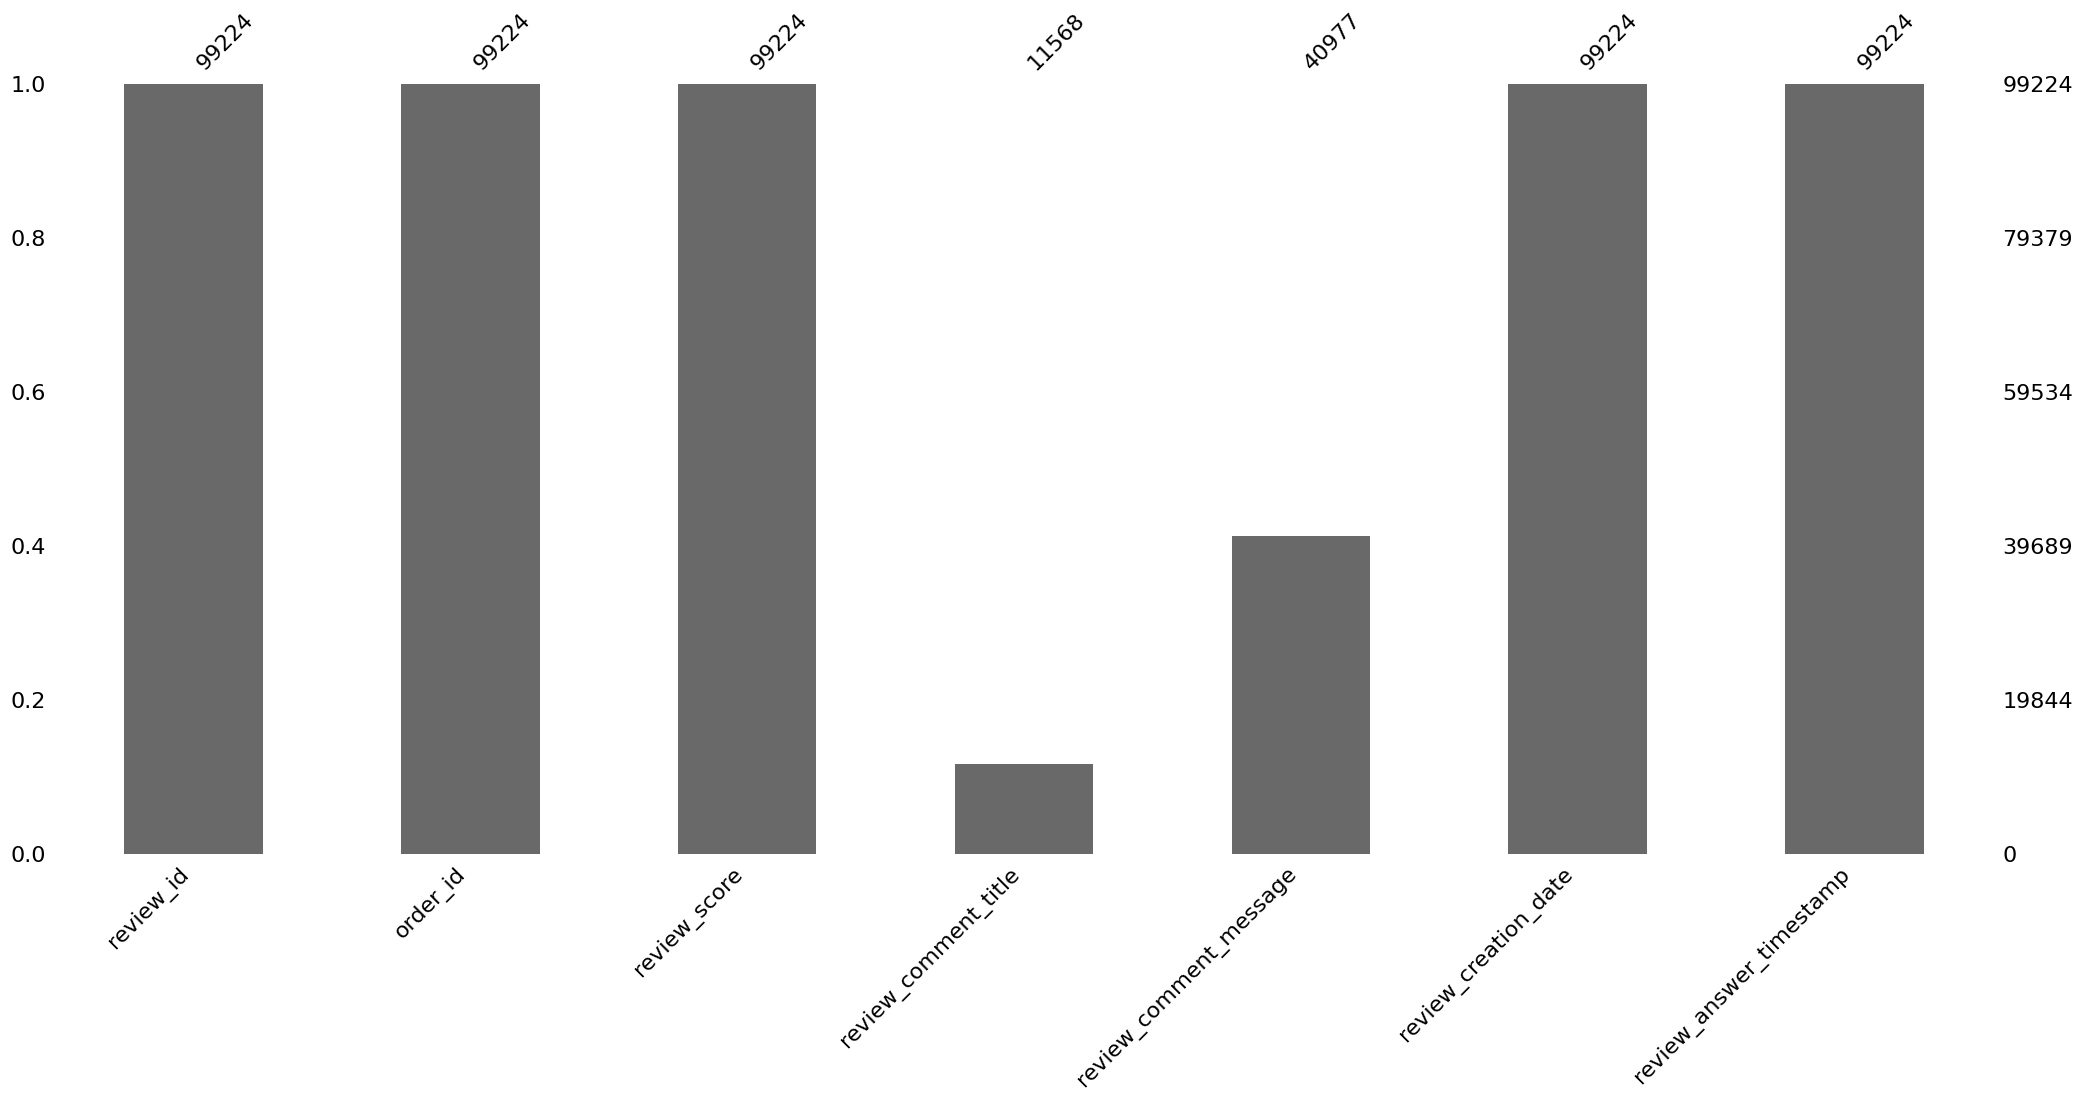

In [66]:
msno.bar(review)
plt.show()

In [68]:
review.duplicated().sum()

np.int64(0)

In [67]:
review.apply(lambda col: col.duplicated().sum())

,0
review_id,814
order_id,551
review_score,99219
review_comment_title,94696
review_comment_message,63064
review_creation_date,98588
review_answer_timestamp,976


In [69]:
review['review_id'].nunique() == len(review)

False

products

In [70]:
prod.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [72]:
prod.shape

(32950, 9)

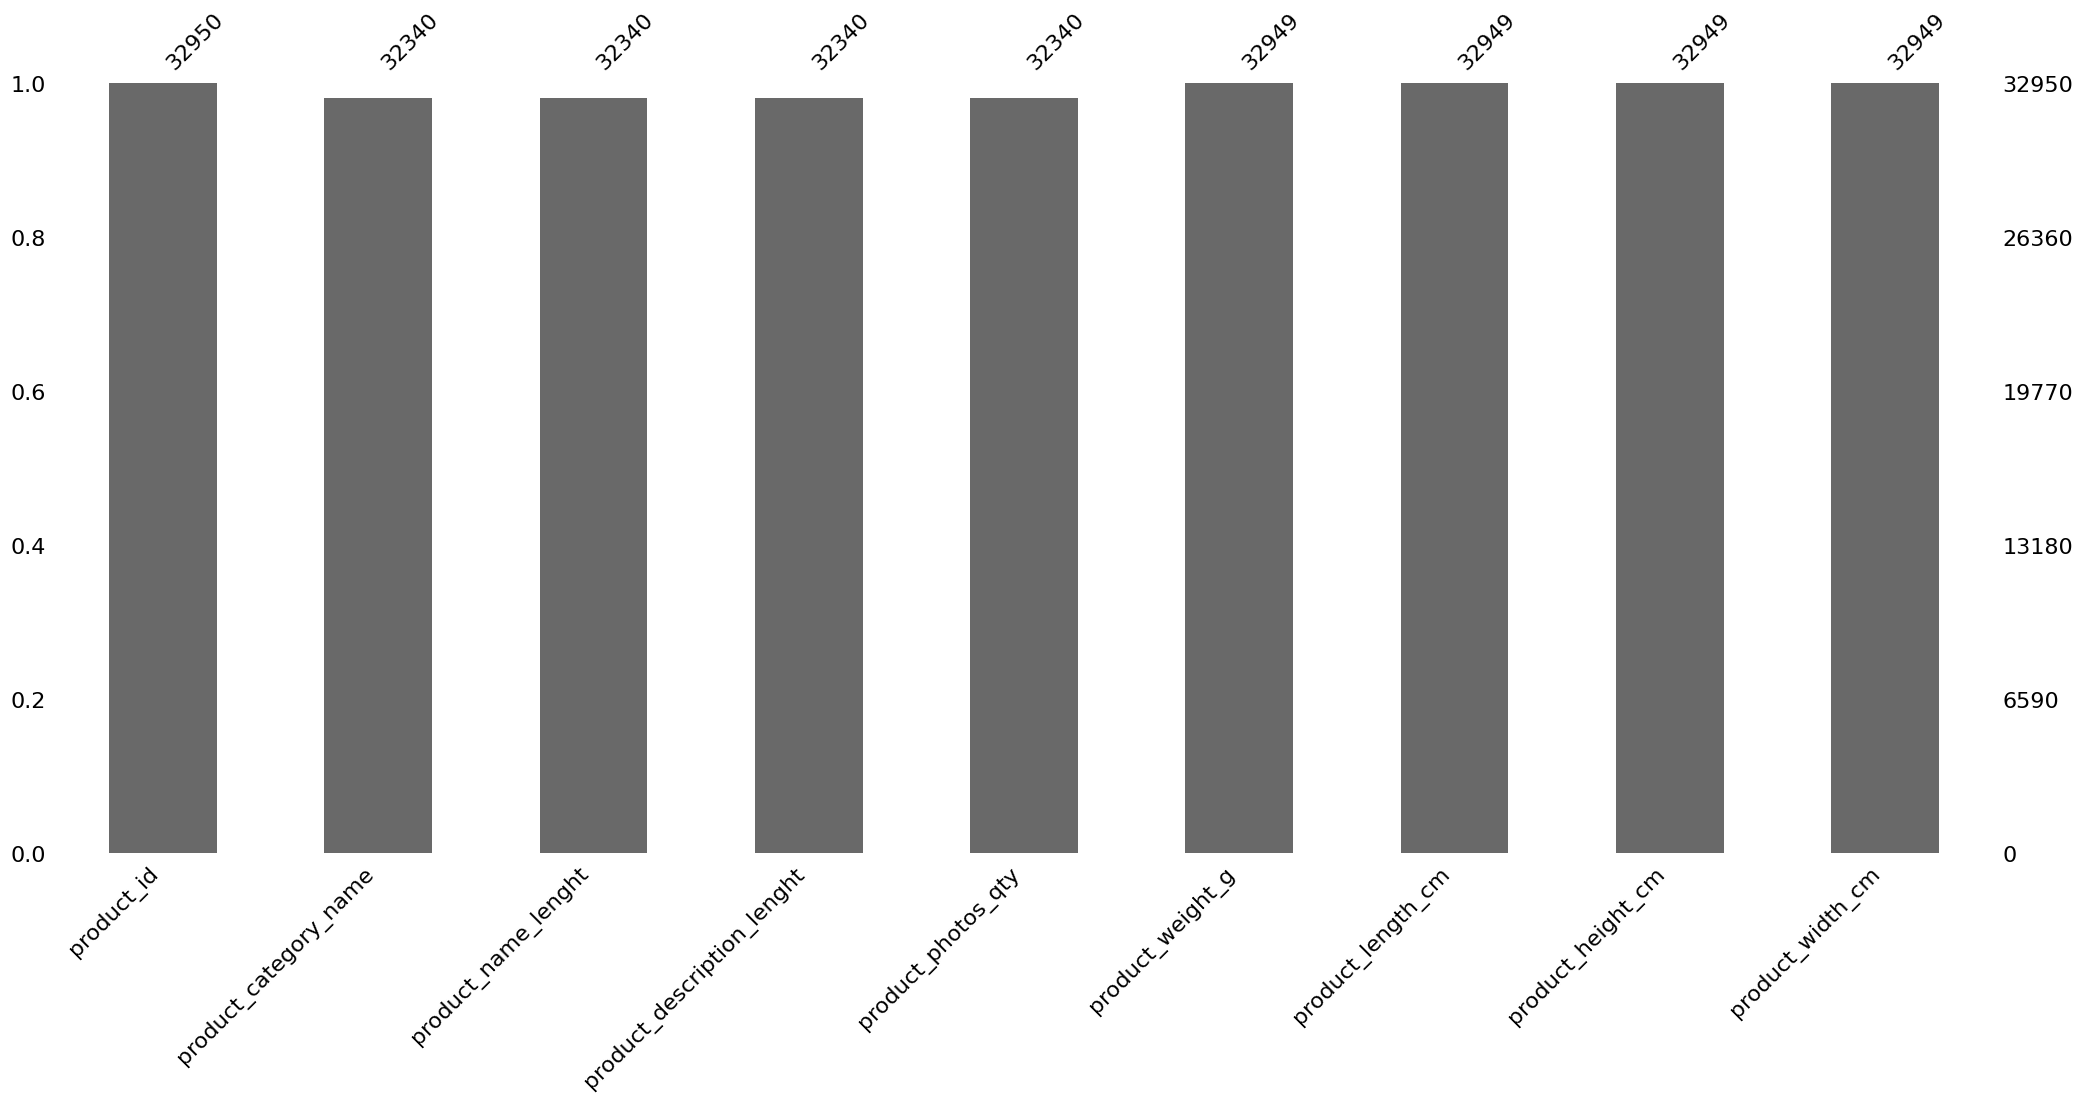

In [71]:
msno.bar(prod)
plt.show()

In [73]:
prod.duplicated().sum()

np.int64(0)

In [74]:
prod.apply(lambda col: col.duplicated().sum())

,0
product_id,0
product_category_name,32876
product_name_lenght,32883
product_description_lenght,29989
product_photos_qty,32930
product_weight_g,30745
product_length_cm,32850
product_height_cm,32847
product_width_cm,32854
